# Vanilla GCN: Full Local Elliptic++ Pipeline

This notebook runs the project pipeline locally through the repository modules. It supports transaction classification by default and wallet-address classification through `configs/actors.yaml`.

The workflow includes sparse loading, graph-derived degree features, random or temporal splits, class-weighted training, fraud metrics, risk ranking, calibration, embedding clustering, and sampled link prediction.

Keep the dataset files in `data/raw/`. The notebook does not use Colab or dense adjacency matrices.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

CONFIG_PATH = PROJECT_ROOT / 'configs' / 'default.yaml'
DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
print('Project root:', PROJECT_ROOT)
print('Config:', CONFIG_PATH)
print('Data directory:', DATA_DIR)

Project root: /Users/s4n/Documents/clg/sem7/mlg/bitcoin-transaction-gcn
Config: /Users/s4n/Documents/clg/sem7/mlg/bitcoin-transaction-gcn/configs/default.yaml
Data directory: /Users/s4n/Documents/clg/sem7/mlg/bitcoin-transaction-gcn/data/raw


In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.optim as optim
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

CONFIG_PATH = PROJECT_ROOT / 'configs' / 'default.yaml'
DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'analysis_notebook'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

from vanilla_gcn.analysis.link_prediction import evaluate_link_prediction
from vanilla_gcn.analysis.risk import cluster_embeddings, expected_calibration_error, risk_ranking
from vanilla_gcn.config import load_config
from vanilla_gcn.data.loader import load_elliptic_actors, load_elliptic_transactions
from vanilla_gcn.data.preprocessing import prepare_graph
from vanilla_gcn.models.vanilla_gcn import VanillaGCN
from vanilla_gcn.seed import set_seed
from vanilla_gcn.training.evaluation import evaluate_gcn
from vanilla_gcn.training.trainer import train_gcn
from vanilla_gcn.utils.checkpointing import save_checkpoint
from vanilla_gcn.utils.logging import setup_logging
from vanilla_gcn.visualization.embeddings import visualize_training_curves

cfg = load_config(CONFIG_PATH)
set_seed(cfg.seed)
setup_logging(level='INFO', log_file=PROJECT_ROOT / cfg.paths.logs / 'notebook_train.log', force=True)
print('Configuration loaded:', CONFIG_PATH)
print('Dataset:', cfg.data.dataset)
print('Split:', cfg.data.split_strategy)
print('Graph features:', cfg.data.add_graph_features)

Configuration loaded: /Users/s4n/Documents/clg/sem7/mlg/bitcoin-transaction-gcn/configs/default.yaml
Dataset: elliptic
Split: random
Graph features: True


## 1. Load the selected Elliptic++ graph

`default.yaml` loads transactions. Change `CONFIG_PATH` to `configs/actors.yaml` for wallet-address classification or `configs/temporal.yaml` for time-aware transaction evaluation.

In [3]:
if cfg.data.dataset == 'elliptic':
    required_files = [
        DATA_DIR / 'txs_features.csv',
        DATA_DIR / 'txs_classes.csv',
        DATA_DIR / 'txs_edgelist.csv',
    ]
    loader = load_elliptic_transactions
elif cfg.data.dataset == 'elliptic_actors':
    required_files = [
        DATA_DIR / 'wallets_features.csv',
        DATA_DIR / 'wallets_classes.csv',
        DATA_DIR / 'AddrAddr_edgelist.csv',
    ]
    loader = load_elliptic_actors
else:
    raise ValueError(f'Unsupported dataset: {cfg.data.dataset!r}')

missing = [str(path) for path in required_files if not path.exists()]
if missing:
    raise FileNotFoundError('Missing dataset files:\n' + '\n'.join('  - ' + path for path in missing))

data = loader(
    raw_dir=DATA_DIR,
    train_ratio=cfg.data.train_ratio,
    val_ratio=cfg.data.validation_ratio,
    test_ratio=cfg.data.test_ratio,
    seed=cfg.seed,
    split_strategy=cfg.data.split_strategy,
    temporal_train_end=cfg.data.temporal_train_end,
    temporal_validation_end=cfg.data.temporal_validation_end,
    add_graph_features=cfg.data.add_graph_features,
)
print(data.summary())
print('Labelled mask:', int(data.labelled_mask.sum()) if data.labelled_mask is not None else 'not available')

2026-10-04 19:33:59 | INFO     | vanilla_gcn.data.loader | Reading features from /Users/s4n/Documents/clg/sem7/mlg/bitcoin-transaction-gcn/data/raw/txs_features.csv …
2026-10-04 19:34:02 | INFO     | vanilla_gcn.data.loader | Reading classes from /Users/s4n/Documents/clg/sem7/mlg/bitcoin-transaction-gcn/data/raw/txs_classes.csv …
2026-10-04 19:34:02 | INFO     | vanilla_gcn.data.loader | Reading edges from /Users/s4n/Documents/clg/sem7/mlg/bitcoin-transaction-gcn/data/raw/txs_edgelist.csv …
2026-10-04 19:34:02 | INFO     | vanilla_gcn.data.loader | Loaded Elliptic++ Transactions: N=203769, F=186, labelled=46564 (illicit=4545, licit=42019), edges=234355
GraphData(name='elliptic_transactions')
  Nodes (N)        : 203769
  Features (F)     : 186
  Classes (C)      : 2
  Directed edges(E): 468710
  Train nodes      : 27938
  Val nodes        : 9312
  Test nodes       : 9314
  adjacency shape  : (203769, 203769)
  features shape   : (203769, 186)
  labels shape     : (203769,)
Labelled mas

/Users/s4n/Documents/clg/sem7/mlg/bitcoin-transaction-gcn/src/vanilla_gcn/data/loader.py:386: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:855.)
  adjacency = torch.sparse_coo_tensor(


## 2. Preprocess the graph

In [4]:
A_hat, A_tilde, X, y = prepare_graph(data.adjacency, data.features, data.labels)
print('Raw adjacency sparse:', data.adjacency.is_sparse)
print('Normalized adjacency sparse:', A_tilde.is_sparse)
print('Normalized adjacency entries:', A_tilde._nnz() if A_tilde.is_sparse else 'dense')
print('Feature shape:', tuple(X.shape))

2026-10-04 19:34:02 | INFO     | vanilla_gcn.data.preprocessing | prepare_graph: starting GCN preprocessing pipeline
2026-10-04 19:34:02 | INFO     | vanilla_gcn.data.preprocessing |   Input A shape : (203769, 203769)
2026-10-04 19:34:02 | INFO     | vanilla_gcn.data.preprocessing |   Input X shape : (203769, 186)
2026-10-04 19:34:02 | INFO     | vanilla_gcn.data.preprocessing |   Input y shape : (203769,)
2026-10-04 19:34:02 | INFO     | vanilla_gcn.data.preprocessing |   Â (after self-loops) shape : (203769, 203769)
2026-10-04 19:34:02 | INFO     | vanilla_gcn.data.preprocessing |   Ã (normalized) shape : (203769, 203769)
Raw adjacency sparse: True
Normalized adjacency sparse: True
Normalized adjacency entries: 672479
Feature shape: (203769, 186)


## 3. Build and train the configured Vanilla GCN

In [5]:
class_weights = None
if cfg.training.class_weighted_loss:
    counts = torch.bincount(data.labels[data.train_mask], minlength=data.num_classes).float()
    class_weights = counts.sum() / (data.num_classes * counts.clamp_min(1.0))
    print('Class weights:', class_weights.tolist())

model = VanillaGCN(
    input_dim=data.num_features,
    hidden_dim=cfg.model.hidden_dim,
    num_classes=data.num_classes,
    num_layers=cfg.model.num_layers,
    dropout=cfg.model.dropout,
    debug=cfg.debug.enabled,
)
model.print_summary()

history = train_gcn(
    model=model,
    A_tilde=A_tilde,
    X=X,
    y=y,
    train_mask=data.train_mask,
    val_mask=data.val_mask,
    epochs=cfg.training.epochs,
    lr=cfg.training.learning_rate,
    weight_decay=cfg.training.weight_decay,
    class_weights=class_weights,
)

Class weights: [5.105628490447998, 0.5542814135551453]
2026-10-04 19:34:02 | INFO     | vanilla_gcn.models.vanilla_gcn | VanillaGCN created: input_dim=186, hidden_dim=64, num_classes=2, num_layers=2, dropout=0.50
┌─────────────────────────────────────────┐
│              Vanilla GCN                │
├─────────────────────────────────────────┤
│  Input features     (N × 186)
│     ↓
│  GCN Layer 1             186 → 64  activation=relu
│     ↓
│  Output Layer (Logits)   64 → 2  activation=None
│     ↓
│  Logits             (N × 2)
├─────────────────────────────────────────┤
│  Total trainable parameters: 12032
└─────────────────────────────────────────┘
2026-10-04 19:34:03 | INFO     | vanilla_gcn.training.trainer | Starting GCN training: epochs=200, lr=0.0010, wd=0.000500
2026-10-04 19:34:03 | INFO     | vanilla_gcn.training.trainer | Epoch 001 | Train Loss: 13.6032 | Train Acc: 79.8% | Val Loss: 9.8355 | Val Acc: 80.1%
2026-10-04 19:34:04 | INFO     | vanilla_gcn.training.trainer | Epo

## 4. Evaluate the trained model

In [6]:
metrics = evaluate_gcn(
    model,
    A_tilde,
    X,
    y,
    data.train_mask,
    data.val_mask,
    data.test_mask,
    class_weights=class_weights,
)
print(history.summary())
print(metrics.summary())

2026-10-04 19:34:27 | INFO     | vanilla_gcn.training.evaluation | Evaluation Metrics
  Train loss : 0.2985  |  Train acc : 86.4%
  Val   loss : 0.3133  |  Val   acc : 86.0%
  Test  loss : 0.3118  |  Test  acc : 86.6%
  Test fraud: F1=0.565 | Recall=0.894 | PR-AUC=0.660
TrainingHistory over 200 epochs
  Final train loss : 0.2989
  Final val   loss : 0.3133
  Final train acc  : 86.4%
  Final val   acc  : 86.0%
  Best val    acc  : 89.9% (epoch 11)
  Total time       : 23.60s
Evaluation Metrics
  Train loss : 0.2985  |  Train acc : 86.4%
  Val   loss : 0.3133  |  Val   acc : 86.0%
  Test  loss : 0.3118  |  Test  acc : 86.6%
  Test fraud: F1=0.565 | Recall=0.894 | PR-AUC=0.660


2026-10-04 19:34:27 | INFO     | vanilla_gcn.utils.checkpointing | Checkpoint saved: epoch=200, val_acc=89.9%, path=/Users/s4n/Documents/clg/sem7/mlg/bitcoin-transaction-gcn/outputs/checkpoints/vanilla_gcn_notebook.pt
2026-10-04 19:34:27 | INFO     | vanilla_gcn.visualization.embeddings | Training curves saved to /Users/s4n/Documents/clg/sem7/mlg/bitcoin-transaction-gcn/outputs/figures/training_curves_notebook.png
Checkpoint: /Users/s4n/Documents/clg/sem7/mlg/bitcoin-transaction-gcn/outputs/checkpoints/vanilla_gcn_notebook.pt
Training curves: /Users/s4n/Documents/clg/sem7/mlg/bitcoin-transaction-gcn/outputs/figures/training_curves_notebook.png


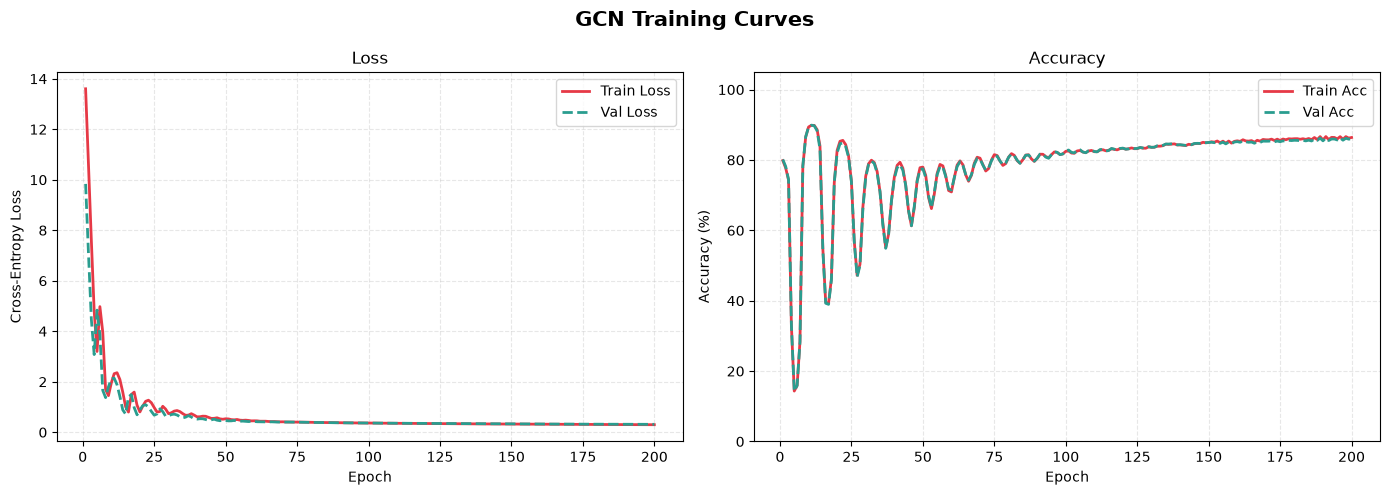

In [7]:
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg.training.learning_rate,
    weight_decay=cfg.training.weight_decay,
)
checkpoint_path = PROJECT_ROOT / cfg.paths.checkpoints / 'vanilla_gcn_notebook.pt'
save_checkpoint(model, optimizer, cfg, history, epoch=cfg.training.epochs, path=checkpoint_path)

figures_dir = PROJECT_ROOT / cfg.paths.figures
figures_dir.mkdir(parents=True, exist_ok=True)
curves_path = figures_dir / 'training_curves_notebook.png'
visualize_training_curves(
    history.train_loss,
    history.val_loss,
    history.train_acc,
    history.val_acc,
    history.epochs,
    save_path=curves_path,
)
print('Checkpoint:', checkpoint_path)
print('Training curves:', curves_path)

## 5. Risk ranking, calibration, and embedding clusters

In [8]:
model.eval()
with torch.no_grad():
    outputs = model(X, A_tilde, return_intermediate=True)
    logits = outputs['logits']
    hidden_keys = [key for key in outputs.keys() if key not in {'input', 'logits'}]
    embeddings = outputs[hidden_keys[-1]] if hidden_keys else outputs['input']

analysis_labels = data.labels.clone()
if data.labelled_mask is not None:
    analysis_labels[~data.labelled_mask] = -1

ranking = risk_ranking(
    logits,
    data.node_ids,
    analysis_labels,
    top_k=100,
)
risk_path = OUTPUT_DIR / 'risk_ranking.csv'
ranking.to_csv(risk_path, index=False)

probabilities = torch.softmax(logits, dim=1)[:, 0].detach().cpu().numpy()
test_indices = data.test_mask.cpu().numpy()
test_labels = analysis_labels.cpu().numpy()[test_indices]
ece = expected_calibration_error(probabilities[test_indices], test_labels)

assignments, cluster_summary, cluster_metrics = cluster_embeddings(
    embeddings,
    analysis_labels,
    n_clusters=8,
    sample_size=10_000,
    seed=cfg.seed,
)
cluster_path = OUTPUT_DIR / 'embedding_clusters.csv'
cluster_summary.to_csv(cluster_path, index=False)
np.save(OUTPUT_DIR / 'cluster_assignments.npy', assignments)

print('Top suspicious nodes:')
display(ranking.head(10))
print(f'Test expected calibration error: {ece:.4f}')
print('Cluster metrics:', cluster_metrics)
print('Risk output:', risk_path)
print('Cluster output:', cluster_path)

Top suspicious nodes:


,node_id,illicit_probability,predicted_class,entropy,true_class
0,139273997,1.0,0,8.072975e-07,-1
1,163654533,1.0,0,3.245369e-07,-1
2,288404361,1.0,0,3.636390e-08,-1
3,355174807,1.0,0,2.143147e-09,-1
4,156158840,1.0,0,4.401082e-10,-1
5,55131476,1.0,0,3.275140e-10,-1
6,157226818,1.0,0,2.516783e-11,-1
7,99332126,1.0,0,5.415709e-12,1
8,241512682,1.0,0,1.671272e-13,-1
9,97134423,1.0,0,1.097950e-14,-1


Test expected calibration error: 0.1452
Cluster metrics: {'silhouette': 0.4835812449455261, 'adjusted_rand_index': 0.05334939946446743, 'normalized_mutual_info': 0.021392212056327933}
Risk output: /Users/s4n/Documents/clg/sem7/mlg/bitcoin-transaction-gcn/outputs/analysis_notebook/risk_ranking.csv
Cluster output: /Users/s4n/Documents/clg/sem7/mlg/bitcoin-transaction-gcn/outputs/analysis_notebook/embedding_clusters.csv


## 6. Sampled embedding link prediction

In [9]:
link_metrics = evaluate_link_prediction(
    embeddings,
    data.edge_index,
    negative_count=100_000,
    seed=cfg.seed,
)
print('Sampled link prediction metrics:')
for name, value in link_metrics.items():
    print(f'  {name}: {value:.4f}')

Sampled link prediction metrics:
  roc_auc: 0.7972
  average_precision: 0.9497
  positive_edges: 468710.0000
  negative_edges: 100000.0000
